In [1]:
import pandas as pd
train_data = pd.read_csv("./data/train_users.csv")

In [2]:
train_data

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213446,zxodksqpep,2014-06-30,20140630235636,NaN,MALE,32.0,basic,0,en,sem-brand,google,omg,Web,Mac Desktop,Safari,NDF
213447,mhewnxesx9,2014-06-30,20140630235719,NaN,-unknown-,NaN,basic,0,en,direct,direct,linked,Web,Windows Desktop,Chrome,NDF
213448,6o3arsjbb4,2014-06-30,20140630235754,NaN,-unknown-,32.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,NDF
213449,jh95kwisub,2014-06-30,20140630235822,NaN,-unknown-,NaN,basic,25,en,other,other,tracked-other,iOS,iPhone,Mobile Safari,NDF


In [3]:
sessions = pd.read_csv("./data/sessions.csv")

In [4]:
sessions

,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0
3,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,22141.0
4,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,435.0
...,...,...,...,...,...,...
10567732,9uqfg8txu3,dashboard,view,dashboard,Windows Desktop,556.0
10567733,9uqfg8txu3,edit,view,edit_profile,Windows Desktop,6624.0
10567734,9uqfg8txu3,webcam_upload,-unknown-,-unknown-,Windows Desktop,200125.0
10567735,9uqfg8txu3,active,-unknown-,-unknown-,-unknown-,17624.0


So at first look at the data train_data looks like destinations with features while sessions looks like user avtivity data.
First several questions I need to answer
1. What is the target (guessing country destination)
2. What are the target values
3. How many unique users are there
4. If NDF is indeed unknown--that is going to present a different type of challenge

In [5]:
# Had to ask a question here--what is NDF
# Suspect its a no destination found or similar as all the other codes are 2 letter country codes
# or 'other'
# sent question about this
train_data['country_destination'].unique()

<StringArray>
['NDF', 'US', 'other', 'FR', 'CA', 'GB', 'ES', 'IT', 'PT', 'NL', 'DE', 'AU']
Length: 12, dtype: str

In [6]:
# lets look at ids
train_data['id'].unique()

# I did a value counts just to verify that each id was in there one time only.

<StringArray>
['gxn3p5htnn', '820tgsjxq7', '4ft3gnwmtx', 'bjjt8pjhuk', '87mebub9p4',
 'osr2jwljor', 'lsw9q7uk0j', '0d01nltbrs', 'a1vcnhxeij', '6uh8zyj2gn',
 ...
 'omlc9iku7t', 'rf0ay567js', '0k26r3mir0', '40o1ivh6cb', 'qbxza0xojf',
 'zxodksqpep', 'mhewnxesx9', '6o3arsjbb4', 'jh95kwisub', 'nw9fwlyb5f']
Length: 213451, dtype: str

In [7]:

dest = train_data['country_destination'].value_counts()

<BarContainer object of 12 artists>

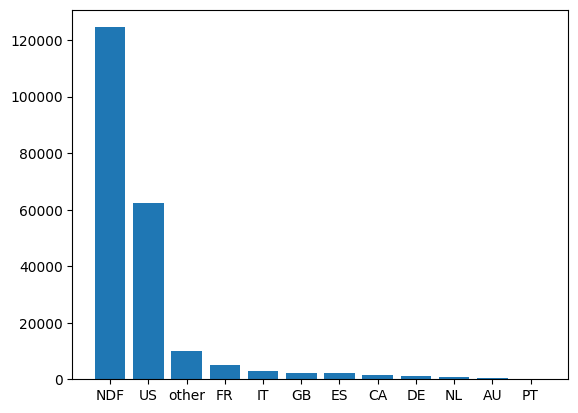

In [8]:
import matplotlib.pyplot as plt
plt.bar(dest.index, dest.values)
#lots of NDF. 12 categories.  Unbalanced.

In [9]:
# Look at the data
train_data.columns

Index(['id', 'date_account_created', 'timestamp_first_active',
       'date_first_booking', 'gender', 'age', 'signup_method', 'signup_flow',
       'language', 'affiliate_channel', 'affiliate_provider',
       'first_affiliate_tracked', 'signup_app', 'first_device_type',
       'first_browser', 'country_destination'],
      dtype='str')

In [10]:
train_data.describe()

,timestamp_first_active,age,signup_flow
count,2.134510e+05,125461.000000,213451.000000
mean,2.013085e+13,49.668335,3.267387
std,9.253717e+09,155.666612,7.637707
min,2.009032e+13,1.000000,0.000000
25%,2.012123e+13,28.000000,0.000000
50%,2.013091e+13,34.000000,0.000000
75%,2.014031e+13,43.000000,0.000000
max,2.014063e+13,2014.000000,25.000000


In [11]:
for col in train_data.columns:
    if col not in ['id','timestamp_first_active','age','signup_flow']:
        print(f"{col} unique values and counts")
        print(train_data[col].value_counts())

date_account_created unique values and counts
date_account_created
2014-05-13    674
2014-06-24    670
2014-06-25    636
2014-05-20    632
2014-05-14    622
             ... 
2010-03-09      1
2010-04-01      1
2010-04-11      1
2010-04-24      1
2010-06-18      1
Name: count, Length: 1634, dtype: int64
date_first_booking unique values and counts
date_first_booking
2014-05-22    248
2014-06-11    231
2014-06-24    226
2014-05-21    225
2014-06-10    223
             ... 
2015-06-14      1
2015-06-26      1
2015-06-25      1
2015-06-29      1
2015-06-28      1
Name: count, Length: 1976, dtype: int64
gender unique values and counts
gender
-unknown-    95688
FEMALE       63041
MALE         54440
OTHER          282
Name: count, dtype: int64
signup_method unique values and counts
signup_method
basic       152897
facebook     60008
google         546
Name: count, dtype: int64
language unique values and counts
language
en    206314
zh      1632
fr      1172
es       915
ko       747
de       

In [12]:
# Intention is to CV so some of these values are super low.  
#First shot I'll try a cutoff value of 5 for any features that occur 5 times or less and put them in a "rare" category

In [13]:
train_data

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213446,zxodksqpep,2014-06-30,20140630235636,NaN,MALE,32.0,basic,0,en,sem-brand,google,omg,Web,Mac Desktop,Safari,NDF
213447,mhewnxesx9,2014-06-30,20140630235719,NaN,-unknown-,NaN,basic,0,en,direct,direct,linked,Web,Windows Desktop,Chrome,NDF
213448,6o3arsjbb4,2014-06-30,20140630235754,NaN,-unknown-,32.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,NDF
213449,jh95kwisub,2014-06-30,20140630235822,NaN,-unknown-,NaN,basic,25,en,other,other,tracked-other,iOS,iPhone,Mobile Safari,NDF


In [14]:
train_data.loc[train_data['date_first_booking'].isna(),"country_destination"].unique()
# think I just answered my own question here.  -NDF means no booking as first travel is null

<StringArray>
['NDF']
Length: 1, dtype: str

In [15]:
train_data.loc[train_data['date_first_booking'].isna(),"signup_flow"].unique()

array([ 0,  3,  2,  1,  6,  5,  8, 25,  4, 10, 24, 12, 16, 15, 20, 21, 23])

In [16]:
for col in train_data.columns:
    missing = train_data.loc[train_data[col].isna(),:].shape[0]
    if missing > 0:
        print(f"{col} has missing rows: {train_data.loc[train_data[col].isna(),:].shape[0]}")

date_first_booking has missing rows: 124543
age has missing rows: 87990
first_affiliate_tracked has missing rows: 6065


In [17]:
train_data.loc[train_data['age']<18,'age'].value_counts()

age
17.0    67
5.0     45
16.0    26
15.0     8
2.0      7
4.0      3
1.0      2
Name: count, dtype: int64

In [18]:
#Number of paths to take.  These look like types.  I could just put limits.  I chose 18 as it is highly unlikequely someone is booking travel under 18
# I chose upper limit of 120 as most humans do not live past that age or travel past 110.  Clearly most of these are years
# I'll probably just impute the mean
train_data.loc[train_data['age']>120,'age'].value_counts()


age
2014.0    710
2013.0     39
1949.0      3
1931.0      3
1932.0      3
1928.0      2
1936.0      2
1924.0      2
1929.0      2
1947.0      2
1933.0      1
1935.0      1
1925.0      1
1952.0      1
150.0       1
1927.0      1
132.0       1
1953.0      1
1942.0      1
1995.0      1
2008.0      1
1938.0      1
1926.0      1
Name: count, dtype: int64

<Axes: >

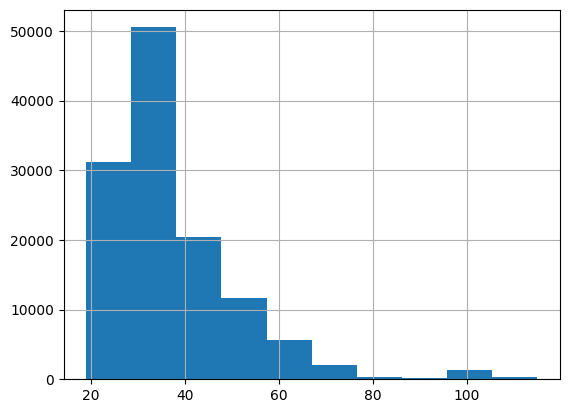

In [19]:
train_data.loc[(train_data['age']<120) & (train_data['age']>18),'age'].hist()
#not happy with that 100+ "bump" as logically as if we don't see a bump around retirement

In [20]:
train_data.loc[(train_data['age']<120) & (train_data['age']>18),'age'].mean()

np.float64(37.5488845647663)

In [21]:
# I plugged in various cutoffs and the median and mean sit at 34 (median) to 36-37 (mean depending on cutoff of "bad values")
# plan is over 90, treat as error and impute median.  Other wise missing, impute median
first_booked = train_data.loc[~train_data['date_first_booking'].isna(),]

In [22]:
first_booked

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US
5,osr2jwljor,2010-01-01,20100101215619,2010-01-02,-unknown-,NaN,basic,0,en,other,other,omg,Web,Mac Desktop,Chrome,US
6,lsw9q7uk0j,2010-01-02,20100102012558,2010-01-05,FEMALE,46.0,basic,0,en,other,craigslist,untracked,Web,Mac Desktop,Safari,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213415,7plqriggxp,2014-06-30,20140630230136,2014-06-30,-unknown-,55.0,basic,0,en,sem-brand,google,omg,Web,Android Tablet,IE,FR
213439,msucfwmlzc,2014-06-30,20140630234729,2015-03-16,MALE,43.0,basic,0,en,direct,direct,untracked,Web,Windows Desktop,Firefox,US
213441,omlc9iku7t,2014-06-30,20140630235151,2014-08-13,FEMALE,34.0,basic,0,en,direct,direct,linked,Web,Mac Desktop,Chrome,ES
213443,0k26r3mir0,2014-06-30,20140630235340,2014-07-13,FEMALE,36.0,basic,0,en,sem-brand,google,linked,Web,Mac Desktop,Safari,US


In [23]:
for col in first_booked.columns:
    print(col, first_booked[col].dtype)

id str
date_account_created str
timestamp_first_active int64
date_first_booking str
gender str
age float64
signup_method str
signup_flow int64
language str
affiliate_channel str
affiliate_provider str
first_affiliate_tracked str
signup_app str
first_device_type str
first_browser str
country_destination str


In [24]:
#convert to unix time (1E9 to get rid of miseconds)
first_booked['date_account_created']=pd.to_datetime(first_booked['date_account_created'], format="%Y-%m-%d").astype('int64')

2         1285632000
3         1323043200
4         1284422400
5         1262304000
6         1262390400
             ...    
213415    1404086400
213439    1404086400
213441    1404086400
213443    1404086400
213445    1404086400
Name: date_account_created, Length: 88908, dtype: int64

In [26]:
first_booked['date_account_created'][2]

np.int64(1285632000000000)

In [32]:
pd.to_datetime('20100101215619',format="%Y%m%d%H%M%S")

Timestamp('2010-01-01 21:56:19')

In [33]:
first_booked['timestamp_first_active'] = pd.to_datetime(first_booked['timestamp_first_active'],format="%Y%m%d%H%M%S").astype('int64')

In [34]:
first_booked

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
2,4ft3gnwmtx,1285632000000000,1244589167000000,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,1323043200000000,1256968889000000,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,1284422400000000,1260252665000000,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US
5,osr2jwljor,1262304000000000,1262382979000000,2010-01-02,-unknown-,NaN,basic,0,en,other,other,omg,Web,Mac Desktop,Chrome,US
6,lsw9q7uk0j,1262390400000000,1262395558000000,2010-01-05,FEMALE,46.0,basic,0,en,other,craigslist,untracked,Web,Mac Desktop,Safari,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213415,7plqriggxp,1404086400000000,1404169296000000,2014-06-30,-unknown-,55.0,basic,0,en,sem-brand,google,omg,Web,Android Tablet,IE,FR
213439,msucfwmlzc,1404086400000000,1404172049000000,2015-03-16,MALE,43.0,basic,0,en,direct,direct,untracked,Web,Windows Desktop,Firefox,US
213441,omlc9iku7t,1404086400000000,1404172311000000,2014-08-13,FEMALE,34.0,basic,0,en,direct,direct,linked,Web,Mac Desktop,Chrome,ES
213443,0k26r3mir0,1404086400000000,1404172420000000,2014-07-13,FEMALE,36.0,basic,0,en,sem-brand,google,linked,Web,Mac Desktop,Safari,US


In [35]:
first_booked['date_first_booking'] = pd.to_datetime(first_booked['date_first_booking'], format="%Y-%m-%d").astype('int64')

In [36]:
first_booked

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
2,4ft3gnwmtx,1285632000000000,1244589167000000,1280707200000000,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,1323043200000000,1256968889000000,1347062400000000,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,1284422400000000,1260252665000000,1266451200000000,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US
5,osr2jwljor,1262304000000000,1262382979000000,1262390400000000,-unknown-,NaN,basic,0,en,other,other,omg,Web,Mac Desktop,Chrome,US
6,lsw9q7uk0j,1262390400000000,1262395558000000,1262649600000000,FEMALE,46.0,basic,0,en,other,craigslist,untracked,Web,Mac Desktop,Safari,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213415,7plqriggxp,1404086400000000,1404169296000000,1404086400000000,-unknown-,55.0,basic,0,en,sem-brand,google,omg,Web,Android Tablet,IE,FR
213439,msucfwmlzc,1404086400000000,1404172049000000,1426464000000000,MALE,43.0,basic,0,en,direct,direct,untracked,Web,Windows Desktop,Firefox,US
213441,omlc9iku7t,1404086400000000,1404172311000000,1407888000000000,FEMALE,34.0,basic,0,en,direct,direct,linked,Web,Mac Desktop,Chrome,ES
213443,0k26r3mir0,1404086400000000,1404172420000000,1405209600000000,FEMALE,36.0,basic,0,en,sem-brand,google,linked,Web,Mac Desktop,Safari,US


In [39]:
#manual imputation. TOO OLD!
first_booked.loc[first_booked['age'].isna(),'age'] = first_booked['age'].median()

In [40]:
first_booked['signup_method'].value_counts()

signup_method
basic       65051
facebook    23756
google        101
Name: count, dtype: int64

In [41]:
first_booked['language'].value_counts()

language
en    86664
zh      521
fr      399
es      275
de      270
ko      241
ru      110
it      104
ja       84
pt       62
sv       44
nl       35
tr       20
da       19
pl       13
no       13
cs        9
fi        7
el        6
hu        4
th        4
ca        2
is        2
Name: count, dtype: int64

In [49]:
# ok i can make guesses on this, but given time, I create a top 10 and then "other"
tmp = first_booked['language'].value_counts()
lang = tmp[0:10].index.to_list()

In [54]:
first_booked.loc[~first_booked['language'].isin(lang),'language'] = "OTHER"

In [55]:
first_booked['affiliate_channel'].value_counts()

affiliate_channel
direct           59398
sem-brand        11094
sem-non-brand     7150
seo               3955
other             3600
api               2785
content            558
remarketing        368
Name: count, dtype: int64

In [58]:
first_booked['affiliate_provider'].value_counts()
tmp = first_booked['affiliate_provider'].value_counts()
provider = tmp[0:10].index.to_list()

In [59]:
first_booked.loc[~first_booked['affiliate_provider'].isin(provider),'affiliate_provider'] = "OTHER"

In [60]:
first_booked['first_affiliate_tracked'].value_counts()

first_affiliate_tracked
untracked        47739
linked           20102
omg              16425
tracked-other     2290
product            542
marketing           63
local ops            9
Name: count, dtype: int64

In [61]:
first_booked['signup_app'].value_counts()

signup_app
Web        80021
iOS         5511
Moweb       2143
Android     1233
Name: count, dtype: int64

In [62]:
first_booked['first_device_type'].value_counts()

first_device_type
Mac Desktop           42250
Windows Desktop       30152
iPhone                 6417
iPad                   5464
Other/Unknown          2875
Android Phone           715
Desktop (Other)         550
Android Tablet          460
SmartPhone (Other)       25
Name: count, dtype: int64

In [66]:

first_booked['first_browser'].value_counts()
tmp = first_booked['first_browser'].value_counts()
browser = tmp[0:10].index.to_list()
first_booked.loc[~first_booked['first_browser'].isin(browser),'first_browser'] = "OTHER"

In [67]:
first_booked

,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
2,4ft3gnwmtx,1285632000000000,1244589167000000,1280707200000000,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,1323043200000000,1256968889000000,1347062400000000,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,1284422400000000,1260252665000000,1266451200000000,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US
5,osr2jwljor,1262304000000000,1262382979000000,1262390400000000,-unknown-,33.0,basic,0,en,other,other,omg,Web,Mac Desktop,Chrome,US
6,lsw9q7uk0j,1262390400000000,1262395558000000,1262649600000000,FEMALE,46.0,basic,0,en,other,craigslist,untracked,Web,Mac Desktop,Safari,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213415,7plqriggxp,1404086400000000,1404169296000000,1404086400000000,-unknown-,55.0,basic,0,en,sem-brand,google,omg,Web,Android Tablet,IE,FR
213439,msucfwmlzc,1404086400000000,1404172049000000,1426464000000000,MALE,43.0,basic,0,en,direct,direct,untracked,Web,Windows Desktop,Firefox,US
213441,omlc9iku7t,1404086400000000,1404172311000000,1407888000000000,FEMALE,34.0,basic,0,en,direct,direct,linked,Web,Mac Desktop,Chrome,ES
213443,0k26r3mir0,1404086400000000,1404172420000000,1405209600000000,FEMALE,36.0,basic,0,en,sem-brand,google,linked,Web,Mac Desktop,Safari,US


In [74]:
encoded = first_booked.columns.to_list()

In [76]:
for i,j in enumerate(encoded):
    print(i,j)

0 id
1 date_account_created
2 timestamp_first_active
3 date_first_booking
4 gender
5 age
6 signup_method
7 signup_flow
8 language
9 affiliate_channel
10 affiliate_provider
11 first_affiliate_tracked
12 signup_app
13 first_device_type
14 first_browser
15 country_destination


In [79]:
indexes = [4,6,8,9,10,11,12,13,14]
encoded = [encoded[i] for i in indexes]
data = pd.get_dummies(first_booked,columns=encoded)

In [81]:
data = pd.get_dummies(first_booked,columns=encoded)

In [84]:
data['country_destination'].value_counts()

country_destination
US       62376
other    10094
FR        5023
IT        2835
GB        2324
ES        2249
CA        1428
DE        1061
NL         762
AU         539
PT         217
Name: count, dtype: int64

In [87]:
country_data = pd.factorize(data['country_destination'])

In [94]:
data ['country_destination'] = country_data[0]

In [110]:
country_data[1]

Index(['US', 'other', 'FR', 'CA', 'GB', 'ES', 'IT', 'PT', 'NL', 'DE', 'AU'], dtype='str')

In [119]:
data.columns

Index(['id', 'date_account_created', 'timestamp_first_active',
       'date_first_booking', 'age', 'signup_flow', 'country_destination',
       'gender_-unknown-', 'gender_FEMALE', 'gender_MALE', 'gender_OTHER',
       'signup_method_basic', 'signup_method_facebook', 'signup_method_google',
       'language_OTHER', 'language_de', 'language_en', 'language_es',
       'language_fr', 'language_it', 'language_ja', 'language_ko',
       'language_pt', 'language_ru', 'language_zh', 'affiliate_channel_api',
       'affiliate_channel_content', 'affiliate_channel_direct',
       'affiliate_channel_other', 'affiliate_channel_remarketing',
       'affiliate_channel_sem-brand', 'affiliate_channel_sem-non-brand',
       'affiliate_channel_seo', 'affiliate_provider_OTHER',
       'affiliate_provider_bing', 'affiliate_provider_craigslist',
       'affiliate_provider_direct', 'affiliate_provider_facebook',
       'affiliate_provider_facebook-open-graph', 'affiliate_provider_google',
       'affiliate_

In [98]:
# ok let me put this together to create a pipeline
def replace_rare(dataframe, column, num_values=10):
    tmp = dataframe[column].value_counts()
    top_vals = tmp[0:num_values].index.to_list()
    dataframe.loc[~dataframe[column].isin(top_vals),column] = "OTHER"
    return 0

replace_rare(train_data,'country_destination')
    

0

In [99]:
train_data['country_destination'].value_counts()  #ok it works.  

country_destination
NDF      124543
US        62376
other     10094
FR         5023
IT         2835
GB         2324
ES         2249
CA         1428
DE         1061
NL          762
OTHER       756
Name: count, dtype: int64

In [125]:
def replace_rare(dataframe, column, num_values=10):
    tmp = dataframe[column].value_counts()
    top_vals = tmp[0:num_values].index.to_list()
    dataframe.loc[~dataframe[column].isin(top_vals),column] = "OTHER"
    return 0

def data_prep():
    """
    Reads in a hard coded data frame and does cleanup. 
    First it selects only customers that have booked a destination.
    All dates are converted to timestamps
    3 columns have rare data, so I created an "other" category for each
    All Categorical variables are then OHE with get_dummies()
    Target Variauble is encoded.
    Final numeric data frame and map of class to country are returned.
    """
    train_data = pd.read_csv("./data/train_users.csv")
    first_booked = train_data.loc[~train_data['date_first_booking'].isna(),]
    first_booked['timestamp_first_active'] = pd.to_datetime(first_booked['timestamp_first_active'],format="%Y%m%d%H%M%S").astype('int64')
    first_booked['date_account_created']=pd.to_datetime(first_booked['date_account_created'], format="%Y-%m-%d").astype('int64')
    first_booked['date_first_booking'] = pd.to_datetime(first_booked['date_first_booking'], format="%Y-%m-%d").astype('int64')
    rare_data_cols = ['first_device_type','affiliate_provider','language','first_browser']
    encoded = first_booked.columns.to_list()
    for col in rare_data_cols:
        replace_rare(first_booked,col)
    indexes = [4,6,8,9,10,11,12,13,14]
    encoded = [encoded[i] for i in indexes]
    data = pd.get_dummies(first_booked,columns=encoded)
    country_data = pd.factorize(data['country_destination'])
    data ['country_destination'] = country_data[0]
    return data, country_data[1]


In [127]:
tmp.columns

Index(['id', 'date_account_created', 'timestamp_first_active',
       'date_first_booking', 'age', 'signup_flow', 'country_destination',
       'gender_-unknown-', 'gender_FEMALE', 'gender_MALE', 'gender_OTHER',
       'signup_method_basic', 'signup_method_facebook', 'signup_method_google',
       'language_OTHER', 'language_de', 'language_en', 'language_es',
       'language_fr', 'language_it', 'language_ja', 'language_ko',
       'language_pt', 'language_ru', 'language_zh', 'affiliate_channel_api',
       'affiliate_channel_content', 'affiliate_channel_direct',
       'affiliate_channel_other', 'affiliate_channel_remarketing',
       'affiliate_channel_sem-brand', 'affiliate_channel_sem-non-brand',
       'affiliate_channel_seo', 'affiliate_provider_OTHER',
       'affiliate_provider_bing', 'affiliate_provider_craigslist',
       'affiliate_provider_direct', 'affiliate_provider_facebook',
       'affiliate_provider_facebook-open-graph', 'affiliate_provider_google',
       'affiliate_

In [128]:
for i in tmp.columns.to_list():
    if i in (data.columns.to_list()):
        pass
    else:
        print(i)

In [138]:
sample = data[data['id']=='4ft3gnwmtx']

In [144]:
tmp = sample.values

In [148]:
rf_model_best.predict(tmp[0,1:])

NameError: name 'rf_model_best' is not defined